In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\zafarali27\house-price-prediction-dataset\versions\1


In [27]:
from pathlib import Path

csv_files = list(Path(path).rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {path}")

df = pd.read_csv(csv_files[0])
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [28]:
df.shape

(2000, 10)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [30]:
df['target'] = pd.to_numeric(df['Price'], errors='coerce')

In [31]:
df.value_counts().sum()

np.int64(2000)

In [32]:
numeric_df = df.select_dtypes(include=[np.number])

In [33]:
print("Numeric columns in the dataset:")
print(numeric_df.columns)

Numeric columns in the dataset:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price',
       'target'],
      dtype='str')


In [34]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price', 'target'],
      dtype='str')

In [35]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
target       0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df['Id'].nunique()

2000

In [38]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,target
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000,999656.000000


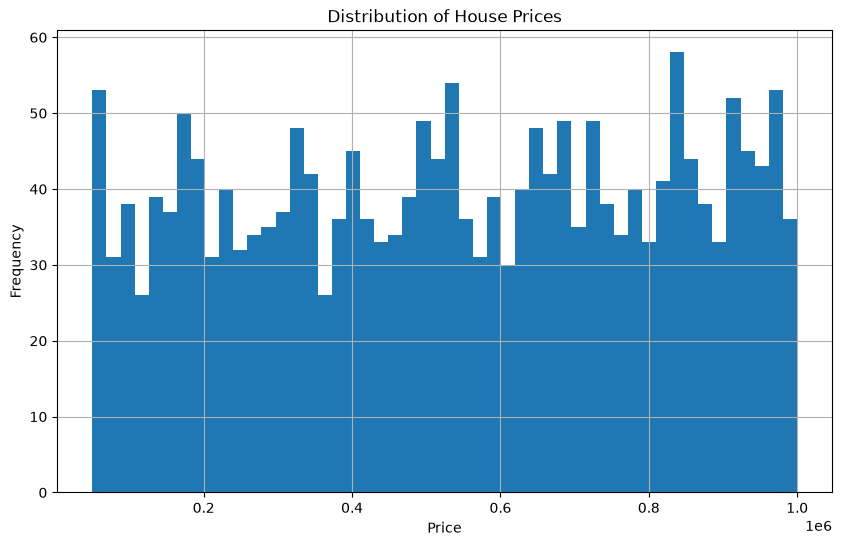

In [39]:
plt.figure(figsize=(10, 6))
df['Price'].hist(bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [40]:
mean_price = df['Price'].mean()
median_price = df['Price'].median()

print(f"Mean price: {mean_price:.2f}")
print(f"Median price: {median_price:.2f}")

Mean price: 537676.85
Median price: 539254.00


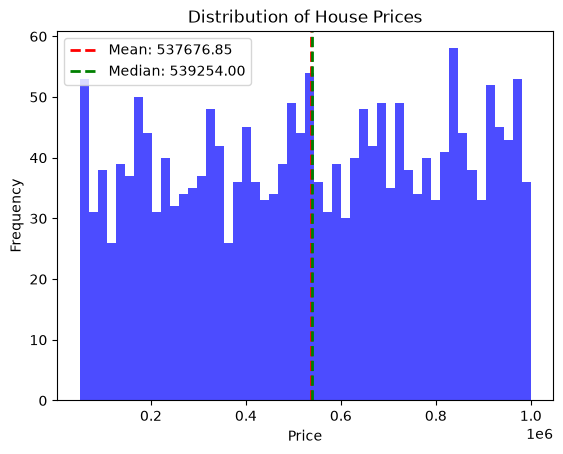

In [41]:
plt.hist(df['Price'], bins=50, alpha=0.7, color='blue')
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_price:.2f}')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [42]:
top_5_expensive = df.nlargest(5, 'Price')
top_5_expensive

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,target
1004,1005,3099,1,2,3,1997,Suburban,Good,No,999656,999656
1787,1788,566,4,1,1,1945,Urban,Fair,Yes,999453,999453
1006,1007,736,3,2,3,1939,Downtown,Good,Yes,998128,998128
1552,1553,2860,2,2,3,1910,Downtown,Fair,No,998084,998084
241,242,2985,4,3,3,1969,Urban,Poor,Yes,997719,997719


In [43]:
print(f"Price range of the houses: {price_range}")

NameError: name 'price_range' is not defined

In [ ]:
print(f"Skewness of the price distribution: {df['Price'].skew()}")

Skewness of the price distribution: -0.06435063707629374


In [ ]:
df['Area'].value_counts()

Area
4219    5
1516    4
3691    4
1743    4
4646    4
       ..
647     1
4827    1
865     1
2174    1
4062    1
Name: count, Length: 1622, dtype: int64

In [ ]:
df['Area'].isnull().sum()

np.int64(0)

In [ ]:
df['Area'].mean()

np.float64(2786.2095)

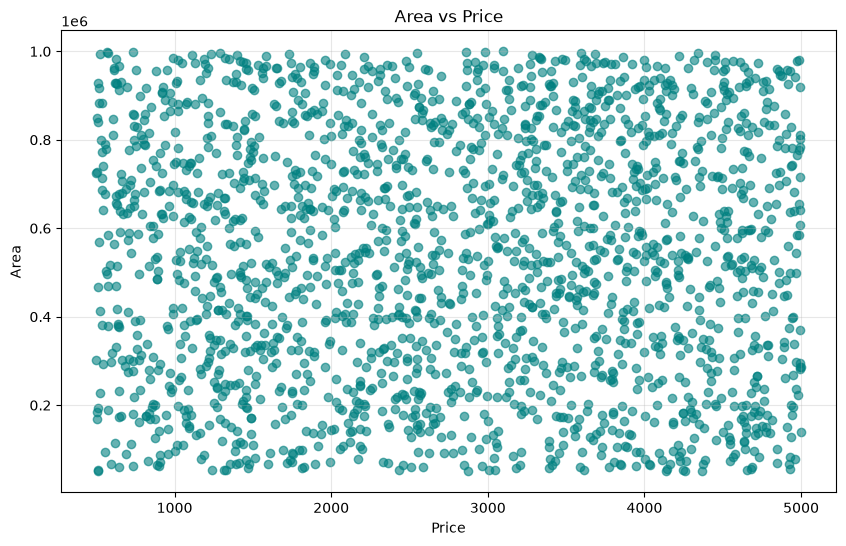

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Area'], df['Price'], alpha=0.6, color='teal')
plt.title('Area vs Price')
plt.xlabel('Price')
plt.ylabel('Area')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print(df['Price'].corr(df['Area']))

0.0015421203243642038


In [ ]:
avg_price = df['Price'].mean()

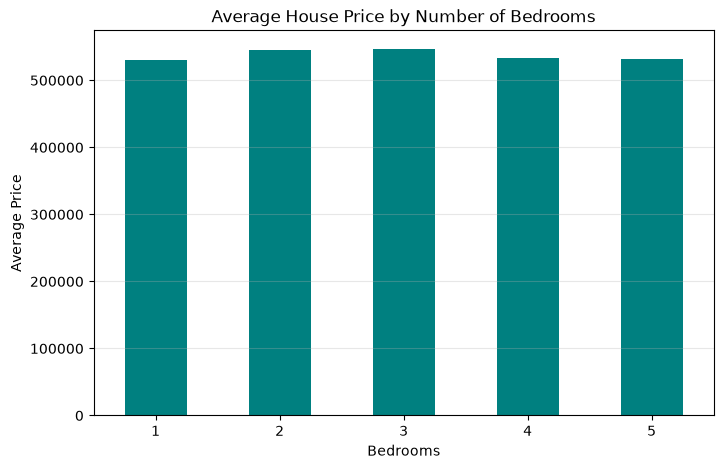

In [ ]:
avg_price_by_bedrooms = df.groupby('Bedrooms')['Price'].mean()

avg_price_by_bedrooms.plot(kind='bar', color='teal', figsize=(8, 5))
plt.title('Average House Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

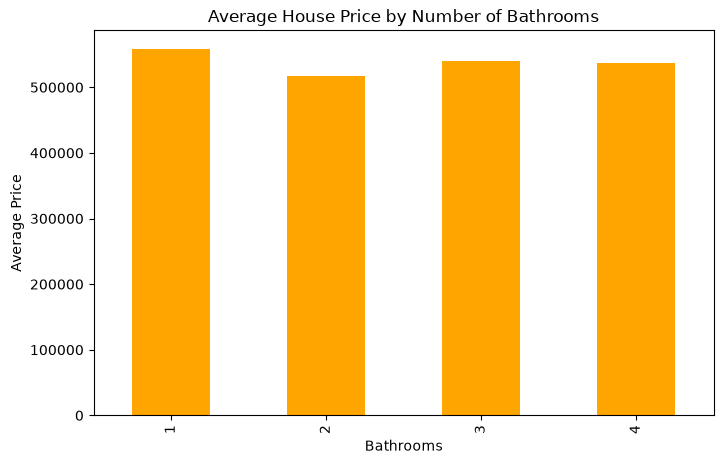

In [ ]:
avg_price_by_bathrooms = df.groupby('Bathrooms')['Price'].mean()
avg_price_by_bathrooms.plot(kind='bar', color='orange', figsize=(8, 5))
plt.title('Average House Price by Number of Bathrooms')     
plt.xlabel('Bathrooms')
plt.ylabel('Average Price')
plt.show()

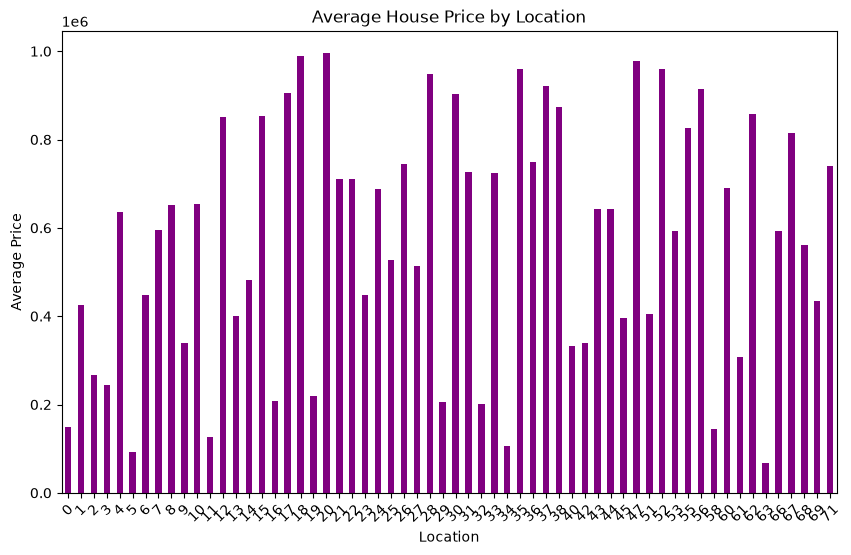

In [ ]:
avg_price_by_locationn = df.groupby('Location')['Price'].head(15)
avg_price_by_locationn.plot(kind='bar', color='purple', figsize=(10, 6))
plt.title('Average House Price by Location')
plt.xlabel('Location')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

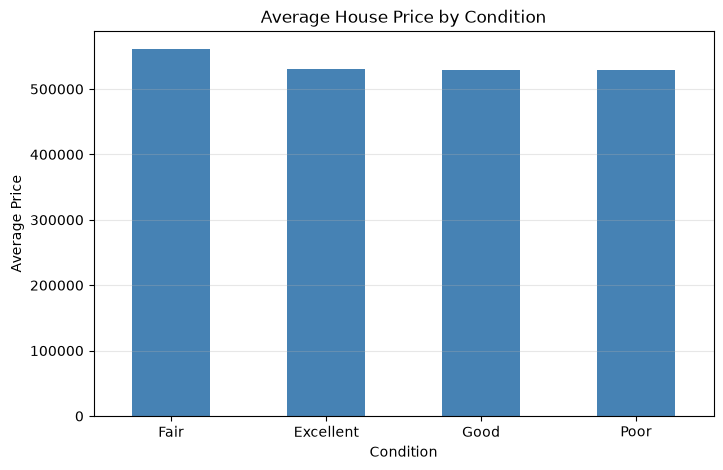

In [ ]:
avg_price_by_condition = df.groupby('Condition')['Price'].mean().sort_values(ascending=False)

avg_price_by_condition.plot(kind='bar', color='steelblue', figsize=(8, 5))
plt.title('Average House Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

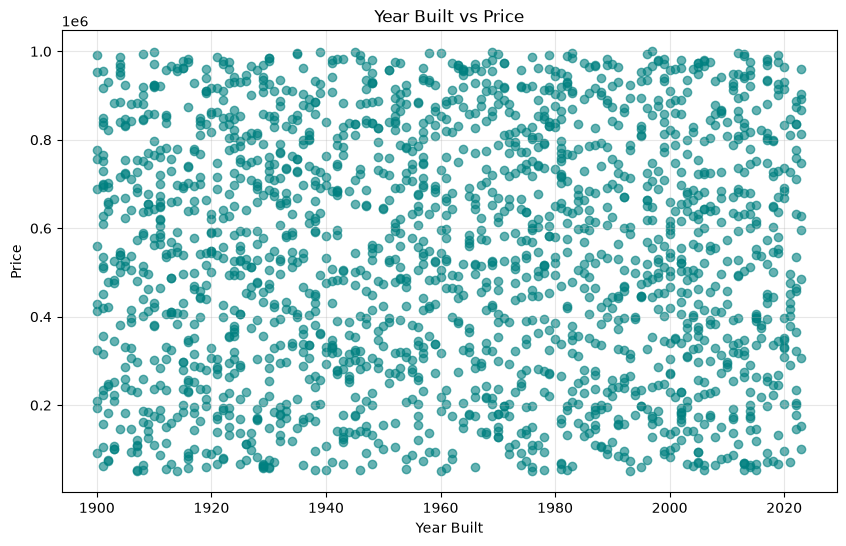

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['YearBuilt'], df['Price'], alpha=0.6, color='teal')

plt.title('Year Built vs Price')
plt.xlabel('Year Built')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.show()

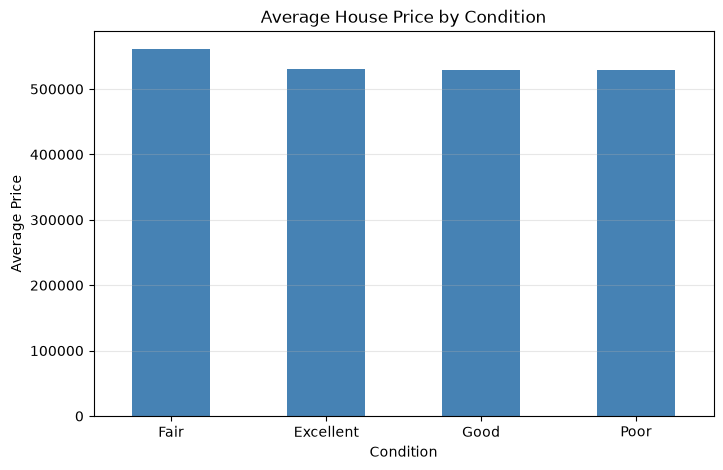

In [ ]:
avg_price_by_condition.plot(kind='bar', color='steelblue', figsize=(8, 5))

plt.title('Average House Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

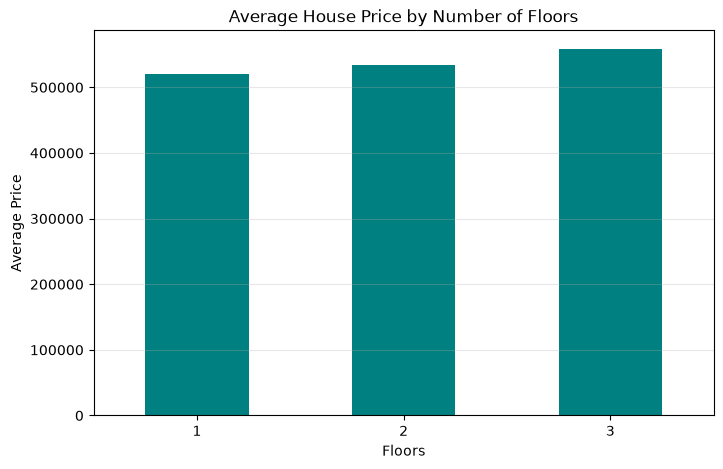

In [ ]:
avg_price_by_floors = df.groupby('Floors')['Price'].mean()

avg_price_by_floors.plot(kind='bar', color='teal', figsize=(8, 5))
plt.title('Average House Price by Number of Floors')
plt.xlabel('Floors')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

correlation_table = (
    df[features + ['Price']]
    .corr()['Price']
    .drop('Price')
    .rename('Correlation with Price')
    .to_frame()
)

correlation_table

,Correlation with Price
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Floors,0.055890
YearBuilt,0.004845


In [ ]:
# Calculate the requested observations
location_avg = df.groupby('Location')['Price'].mean().sort_values()
garage_avg = df.groupby('Garage')['Price'].mean()
bedroom_avg = df.groupby('Bedrooms')['Price'].mean()

area_corr = df['Area'].corr(df['Price'])
yearbuilt_corr = df['YearBuilt'].corr(df['Price'])

strongest_feature = correlation_table['Correlation with Price'].abs().idxmax()
strongest_corr = correlation_table.loc[
    strongest_feature, 'Correlation with Price'
]

print("Area vs Price:")
print(f"Correlation = {area_corr:.4f}")
print("Observation = A very weak relationship exists between area and price.")

print("\nBedrooms:")
print(
    f"Highest/lowest average-price pattern = "
    f"{bedroom_avg.idxmax()} bedrooms has the highest average price "
    f"(${bedroom_avg.max():,.2f}), while {bedroom_avg.idxmin()} bedroom "
    f"has the lowest (${bedroom_avg.min():,.2f})."
)

print("\nBathrooms:")
print(
    f"Observation = Houses with {avg_price_by_bathrooms.idxmax()} bathrooms "
    f"have the highest average price "
    f"(${avg_price_by_bathrooms.max():,.2f})."
)

print("\nLocation:")
print(
    f"Highest average-price location = {location_avg.idxmax()} "
    f"(${location_avg.max():,.2f})"
)
print(
    f"Lowest average-price location = {location_avg.idxmin()} "
    f"(${location_avg.min():,.2f})"
)

print("\nCondition:")
print(
    f"Observation = {avg_price_by_condition.idxmax()} condition houses "
    f"have the highest average price, while "
    f"{avg_price_by_condition.idxmin()} condition houses have the lowest."
)

print("\nGarage:")
print(f"Average price with garage = ${garage_avg.get('Yes', float('nan')):,.2f}")
print(f"Average price without garage = ${garage_avg.get('No', float('nan')):,.2f}")

print("\nYearBuilt vs Price:")
print(f"Correlation = {yearbuilt_corr:.4f}")
print("Observation = Year built has a very weak relationship with price.")

print("\nFloors:")
print(
    f"Observation = Houses with {avg_price_by_floors.idxmax()} floors "
    f"have the highest average price "
    f"(${avg_price_by_floors.max():,.2f})."
)

print("\nStrongest numerical relationship with Price:")
print(f"{strongest_feature} (correlation = {strongest_corr:.4f})")

Area vs Price:
Correlation = 0.0015
Observation = A very weak relationship exists between area and price.

Bedrooms:
Highest/lowest average-price pattern = 3 bedrooms has the highest average price ($546,977.89), while 1 bedroom has the lowest ($530,561.62).

Bathrooms:
Observation = Houses with 1 bathrooms have the highest average price ($558,757.75).

Location:
Highest average-price location = Suburban ($557,416.33)
Lowest average-price location = Urban ($518,963.55)

Condition:
Observation = Fair condition houses have the highest average price, while Poor condition houses have the lowest.

Garage:
Average price with garage = $538,492.75
Average price without garage = $536,920.70

YearBuilt vs Price:
Correlation = 0.0048
Observation = Year built has a very weak relationship with price.

Floors:
Observation = Houses with 3 floors have the highest average price ($558,633.84).

Strongest numerical relationship with Price:
Floors (correlation = 0.0559)


In [ ]:
# 1. Target column
target_is_identical_to_price = df["target"].equals(df["Price"])

print("1. Target column")
print("The 'target' column is the prediction variable.")
print(f"Is target identical to Price? {target_is_identical_to_price}")
print(f"Maximum difference: {(df['target'] - df['Price']).abs().max()}")

# 2. Location categories and counts
print("\n2. Location categories and counts")
print(df["Location"].value_counts())

# 3. Condition categories and counts
print("\n3. Condition categories and counts")
print(df["Condition"].value_counts())

# 4. Garage categories and counts
print("\n4. Garage categories and counts")
print(df["Garage"].value_counts())

# 5. Final features to keep
features_to_keep = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage",
]

print("\n5. Final features to keep")
print(features_to_keep)

# 6. Features to remove and reasons
features_to_remove = {
    "Id": "Unique identifier; it has no meaningful predictive relationship.",
    "Price": "The original target column; including it causes target leakage.",
    "target": "This is the prediction target, not an input feature.",
}

print("\n6. Features to remove and why")
for feature, reason in features_to_remove.items():
    print(f"- {feature}: {reason}")

1. Target column
The 'target' column is the prediction variable.
Is target identical to Price? True
Maximum difference: 0

2. Location categories and counts
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

3. Condition categories and counts
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

4. Garage categories and counts
Garage
No     1038
Yes     962
Name: count, dtype: int64

5. Final features to keep
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']

6. Features to remove and why
- Id: Unique identifier; it has no meaningful predictive relationship.
- Price: The original target column; including it causes target leakage.
- target: This is the prediction target, not an input feature.


In [ ]:

features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 
            'YearBuilt', 'Location', 'Condition', 'Garage']

target = ['Price']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x= df[features]
y= df[target]

In [ ]:
price_bins = pd.qcut(y["Price"], q=10, duplicates="drop")

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins
)

In [ ]:
x_train.shape

(1600, 8)

In [ ]:
x_test.shape

(400, 8)

In [ ]:
y_train.shape

(1600, 1)

In [ ]:
y_test.shape

(400, 1)

In [ ]:
excluded_columns = {"Price", "target", "Id"}

print("Columns in x_train:", x_train.columns.tolist())
print("Contains Price, target, or Id:",
    bool(excluded_columns.intersection(x_train.columns)))

Columns in x_train: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']
Contains Price, target, or Id: False


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

categorical_features = ['Location', 'Condition', 'Garage']
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('numeric', 'passthrough', numeric_features)    
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(x_train, y_train['Price'])

y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test['Price'], y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 244,585.57


In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test["Price"], y_pred))

print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

Root Mean Squared Error (RMSE): 285,683.96


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test["Price"], y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: -0.0681


In [ ]:
# 1. Import required libraries

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:

numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]

categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [ ]:


linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [ ]:
features = numerical_features + categorical_features

X = df[features]
y = df["Price"]

price_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins
)

linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Area','Bedrooms','Bathrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis

In [ ]:
train_pred = linear_model.predict(X_train)

In [ ]:
test_pred = linear_model.predict(X_test)

In [ ]:
# 8. Training MAE

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

print(
    f"Training MAE: {train_mae:,.2f}"
)

Training MAE: 237,789.90


In [ ]:
# 9. Test MAE

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

print(
    f"Test MAE: {test_mae:,.2f}"
)

Test MAE: 238,235.37


In [ ]:
# 10. Test RMSE

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

print(
    f"Test RMSE: {test_rmse:,.2f}"
)

Test RMSE: 276,515.22


In [ ]:
# 11. R²

test_r2 = r2_score(
    y_test,
    test_pred
)

print(
    f"Test R²: {test_r2:.4f}"
)

Test R²: -0.0006


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]

categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
tree_model = Pipeline(
    steps=[
        ('preproccessor', tree_preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ]
)

In [48]:
# Reuse the train split if it already exists; otherwise create it consistently
if "X_train" not in globals():
    if "x_train" in globals():
        X_train = x_train
        X_test = x_test
        y_train = y_train
        y_test = y_test
    else:
        features = [
            "Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt",
            "Location", "Condition", "Garage"
        ]
        X = df[features]
        y = df["Price"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

# Fit the tree model before predicting
tree_model.fit(X_train, y_train)

# Predict on the training set
tree_train_pred = tree_model.predict(X_train)

In [49]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preproccessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Area','Bedrooms','Bathrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [50]:
tree_test_pred = tree_model.predict(X_test)

In [51]:
tree_train_mae = mean_absolute_error(
    y_train,
    tree_train_pred
)

tree_test_mae = mean_absolute_error(
    y_test,
    tree_test_pred
)

tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_test_pred
    )
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_pred
)

In [52]:
print("----- DECISION TREE -----")

print(
    f"Train MAE : {tree_train_mae:,.2f}"
)

print(
    f"Test MAE  : {tree_test_mae:,.2f}"
)

print(
    f"Test RMSE : {tree_test_rmse:,.2f}"
)

print(
    f"Test R²   : {tree_test_r2:.4f}"
)

----- DECISION TREE -----
Train MAE : 0.00
Test MAE  : 333,533.60
Test RMSE : 406,570.51
Test R²   : -1.1247


In [54]:
tree_model = Pipeline(
    steps = [
        ("preprocessor", tree_preprocessor),
        ("regression",DecisionTreeRegressor(random_state=42,max_depth = 5,min_samples_split = 10, min_samples_leaf = 5))
    ])

In [55]:
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.3f}")


Test MAE: 248325.56
Test RMSE: 287557.16
Test R²: -0.063


In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [74]:
rf_preprocessor = ColumnTransformer(
    transformers=[("num","passhrough", numerical_features),
                
                  ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])
    

In [81]:

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Area','Bedrooms','Bathrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis

In [82]:
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

In [83]:
rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_pred
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("----- RANDOM FOREST -----")

print(f"Train MAE : {rf_train_mae:,.2f}")
print(f"Test MAE  : {rf_test_mae:,.2f}")
print(f"Test RMSE : {rf_test_rmse:,.2f}")
print(f"Test R²   : {rf_test_r2:.4f}")

----- RANDOM FOREST -----
Train MAE : 89,856.65
Test MAE  : 253,360.30
Test RMSE : 293,332.71
Test R²   : -0.1060


In [89]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [91]:
linear_cv_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_cv_model = Pipeline([
    ("preprocessor", linear_cv_preprocessor),
    ("regressor", LinearRegression())
])

linear_cv_scores = cross_val_score(
    linear_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

linear_cv_mae = -linear_cv_scores.mean()

print("Linear Regression CV MAE:", linear_cv_mae)

Linear Regression CV MAE: 238911.84205964115


In [95]:
# cross_val_score fits cloned models, so fit the original pipeline first
linear_cv_model.fit(X_train, y_train)

final_predictions = linear_cv_model.predict(X_test)

error_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

error_df["Absolute Error"] = (
    error_df["Actual Price"] - error_df["Predicted Price"]
).abs()

error_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

error_df["Absolute Error"] = (
    error_df["Actual Price"]
    - error_df["Predicted Price"]
).abs()


In [100]:
# Evaluate all trained regression models on the test set
models = {
    "Linear Regression": linear_cv_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions),
    })

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

print("Model evaluation results:")
display(results_df)

# Select the best model by lowest MAE
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

print(f"\nBest model: {best_model_name}")

# Test one real example from the test set
sample_house = X_test.iloc[[0]]
actual_price = y_test.iloc[0]
predicted_price = best_model.predict(sample_house)[0]

print("\nSample prediction:")
display(sample_house)
print(f"Actual price:    ${actual_price:,.2f}")
print(f"Predicted price: ${predicted_price:,.2f}")

# Predict a new house
new_house = pd.DataFrame([{
    "Area": 2500,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "Floors": 2,
    "YearBuilt": 2010,
    "Location": "Suburban",
    "Condition": "Good",
    "Garage": "Yes"
}])

new_price = best_model.predict(new_house)[0]

print("\nNew house prediction:")
display(new_house)
print(f"Estimated price: ${new_price:,.2f}")

Model evaluation results:


,Model,MAE,RMSE,R2
0,Linear Regression,243241.977588,279859.725838,-0.006718
1,Decision Tree,248325.560781,287557.158404,-0.062858
2,Random Forest,253360.299137,293332.714471,-0.105982



Best model: Linear Regression

Sample prediction:


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
1860,633,1,4,2,1901,Urban,Fair,No


Actual price:    $514,764.00
Predicted price: $521,988.22

New house prediction:


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,2500,3,2,2,2010,Suburban,Good,Yes


Estimated price: $542,791.36
